# Limpieza y enriquecimiento — ATFM

Ejecuta las funciones reales de `src/transformacion/transformador.py` sobre
los datos crudos y muestra el efecto de cada regla de limpieza.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.extraccion.extractor import extraer_vuelos_raw
from src.transformacion.transformador import limpiar_vuelos, enriquecer_vuelos

df_raw = extraer_vuelos_raw()
df_raw.shape

2026-06-24 11:53:09 | INFO     | src.extraccion.extractor | Encontrados 1 archivo(s) parquet en C:\Users\veliz\Downloads\PROYECTO_ATFM\data\raw


2026-06-24 11:53:09 | INFO     | src.extraccion.extractor | Leyendo part-00001-a1c89589-f077-4615-bd84-d86ac2fc1497.c000.snappy.parquet


2026-06-24 11:55:02 | INFO     | src.extraccion.extractor | Extracción completada: 97217 filas, 14 columnas


(97217, 14)

## Paso 1: limpieza (nulos, duplicados, duración inválida)

In [2]:
df_limpio = limpiar_vuelos(df_raw)
print('Filas originales:', len(df_raw))
print('Filas tras limpieza:', len(df_limpio))
print('Filas eliminadas:', len(df_raw) - len(df_limpio))

2026-06-24 11:55:04 | INFO     | src.transformacion.transformador | Limpieza: 363 filas eliminadas (nulas/duplicadas/duración inválida) de 97217


Filas originales: 97217
Filas tras limpieza: 96854
Filas eliminadas: 363


## Paso 2: enriquecimiento (fechas, calidad de aeropuerto, métricas de trayectoria)

In [3]:
df_enriquecido = enriquecer_vuelos(df_limpio)
df_enriquecido[[
    'icao24', 'callsign', 'aeropuerto_origen', 'aeropuerto_destino',
    'duracion_minutos', 'distancia_recorrida_km', 'distancia_directa_km',
    'calidad_origen', 'calidad_destino'
]].head(10)

2026-06-24 11:55:07 | INFO     | src.transformacion.transformador | Calculando métricas de trayectoria a partir del track (puede tardar)...


,icao24,callsign,aeropuerto_origen,aeropuerto_destino,duracion_minutos,distancia_recorrida_km,distancia_directa_km,calidad_origen,calidad_destino
0,a01b9e,LFG70,DESCONOCIDO,KVNY,100.983333,1238.536929,1087.760194,sin_dato,media
1,a01c7b,N106RF,MS65,MS65,11.366667,45.058788,1.519942,media,media
2,a01c7b,N106RF,4MS3,MS00,16.500000,57.402576,49.447144,media,media
3,a04276,N11594,KIPJ,KIPJ,29.716667,80.829671,19.101794,media,media
4,a043ec,N116QS,KPDK,LSGG,464.316667,7540.875691,7399.692512,alta,media
5,a03bf4,EJM114,KTEB,KBDL,24.200000,207.431227,166.305514,alta,media
6,a03bf4,EJM114,KLAS,KTEB,237.050000,3676.537526,3583.039520,alta,media
7,a053ba,N120AH,DESCONOCIDO,KHPN,53.900000,381.561314,380.267232,sin_dato,alta
8,a05882,N121MF,KSFO,OR06,76.566667,583.841743,549.765941,alta,media
9,a05882,N121MF,DESCONOCIDO,KSFO,69.350000,457.967128,438.560659,sin_dato,media


## Distribución de la confianza del aeropuerto estimado

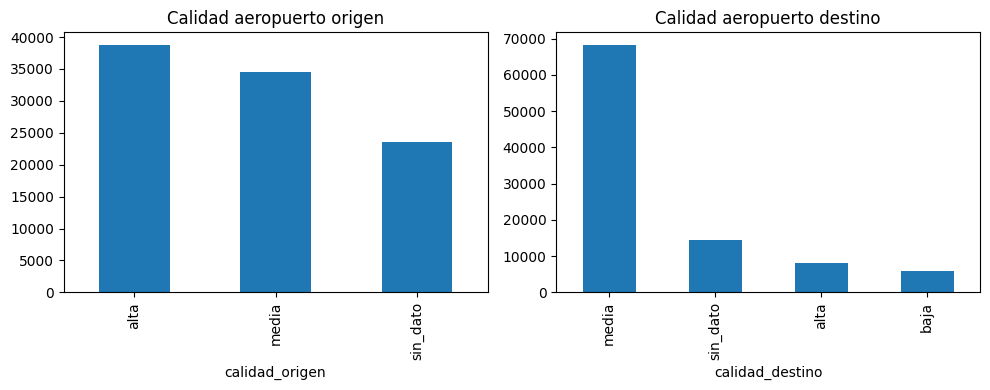

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_enriquecido['calidad_origen'].value_counts().plot(kind='bar', ax=axes[0], title='Calidad aeropuerto origen')
df_enriquecido['calidad_destino'].value_counts().plot(kind='bar', ax=axes[1], title='Calidad aeropuerto destino')
plt.tight_layout()
plt.show()

Una porción de los vuelos queda con calidad `baja` o `sin_dato`: significa que
OpenSky no encontró un aeropuerto suficientemente cercano a la última posición
del track (p. ej. vuelos truncados al borde de la ventana de captura). El
warehouse conserva estos vuelos pero etiquetados como `DESCONOCIDO` en lugar
de descartarlos, para no perder volumen de tráfico real.

## Distribución de la duración de vuelo resultante

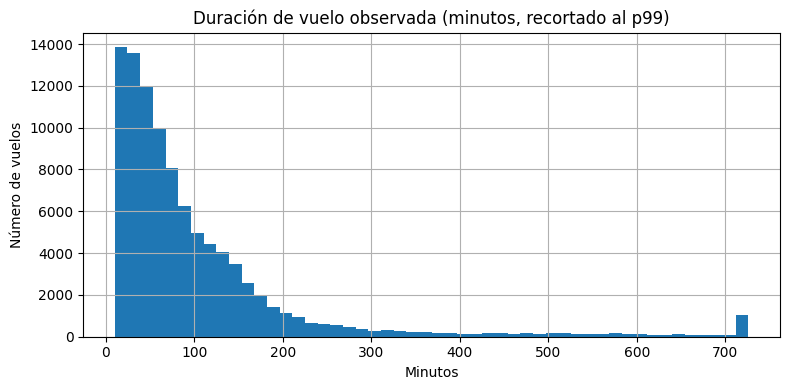

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df_enriquecido['duracion_minutos'].clip(upper=df_enriquecido['duracion_minutos'].quantile(0.99)).hist(bins=50, ax=ax)
ax.set_title('Duración de vuelo observada (minutos, recortado al p99)')
ax.set_xlabel('Minutos')
ax.set_ylabel('Número de vuelos')
plt.tight_layout()
plt.show()